# Stroke Assignment (Programming for Data Analytics and AI)

## Imports and setup

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
import re

In [2]:
from google.colab import drive
drive.mount('/content/drive')
PATH = '/content/drive/MyDrive/Coding/ProgrammingForAI'
!ls /content/drive/MyDrive/Coding/ProgrammingForAI

Mounted at /content/drive
healthcare-dataset-stroke-data.csv  stroke_preprocessed.csv
stroke_clustering_data.csv


In [3]:
OUTPUT_DIR = PATH + '/output'
GLOBAL_SEED = 42

os.environ['PYTHONHASHSEED'] = str(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

In [4]:
def load_data():
    return pd.read_csv(PATH+"/healthcare-dataset-stroke-data.csv")

def load_preprocessed_data(path=PATH+"/stroke_preprocessed.csv"):
    return pd.read_csv(path)

In [5]:
df = load_data()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [7]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np
import re
import os

# --- 1. Settings & Data Prep ---
subset = df.head(5).T

# --- 2. Helper Functions ---

def is_boolean(series):
    """Check if a series is boolean (only contains 0/1 or True/False)."""
    if series.dtype == 'bool':
        return True
    unique_vals = set(series.dropna().unique())
    return unique_vals.issubset({0, 1, 0.0, 1.0})

def get_latex_safe_name(name):
    """Removes spaces and special chars to make a valid LaTeX color name."""
    return re.sub(r'[^a-zA-Z0-9]', '', str(name))

# --- 3. Generate Color Palette for Categoricals ---
categorical_values = set()
for col_name in subset.index:
    # Check if original column is object/category
    if df[col_name].dtype == 'object' or df[col_name].dtype.name == 'category':
        categorical_values.update(subset.loc[col_name].astype(str).unique())

# Generate distinct pastel colors
palette = sns.color_palette("pastel", len(categorical_values))
val_to_color_hex = {
    val: mcolors.to_hex(color).upper()[1:]
    for val, color in zip(sorted(categorical_values), palette)
}

# --- 4. Build the LaTeX String ---

latex_lines = []
latex_lines.append(r"\begin{table}[H]")
latex_lines.append(r"    \centering")
latex_lines.append(r"    \small")
latex_lines.append(r"    % --- Define Boolean Colors ---")
latex_lines.append(r"    \definecolor{boolTrue}{HTML}{C8E6C9} % Green")
latex_lines.append(r"    \definecolor{boolFalse}{HTML}{FFCDD2} % Red")
latex_lines.append(r"")
latex_lines.append(r"    % --- Define Categorical Colors ---")

for val, hex_code in val_to_color_hex.items():
    safe_name = get_latex_safe_name(val)
    latex_lines.append(f"    \\definecolor{{col{safe_name}}}{{HTML}}{{{hex_code}}}")

latex_lines.append(r"")
latex_lines.append(r"    \caption{First 5 rows with boolean and categorical highlighting}")
latex_lines.append(r"    \label{tab:first_5_rows_colored}")

latex_lines.append(r"    \begin{tabular}{@{} l " + "r "*5 + "@{}}")
latex_lines.append(r"        \toprule")

latex_lines.append(r"        \textbf{Feature} & " + " & ".join([f"\\textbf{{{i+1}}}" for i in range(5)]) + r" \\")
latex_lines.append(r"        \midrule")

# --- 5. Iterate Rows and Apply Logic ---
for feature_name, row_data in subset.iterrows():

    orig_col = df[feature_name]
    row_cells = []

    # A. Boolean Logic
    if is_boolean(orig_col):
        for val in row_data:
            if val == 1 or val is True:
                row_cells.append(r"\cellcolor{boolTrue}1")
            else:
                row_cells.append(r"\cellcolor{boolFalse}0")

    # B. Categorical Logic
    elif orig_col.dtype == 'object' or orig_col.dtype.name == 'category':
        for val in row_data:
            val_str = str(val)
            safe_name = get_latex_safe_name(val_str)
            row_cells.append(f"\\cellcolor{{col{safe_name}}}{{{val_str}}}")

    # C. Numerical Logic
    else:
        for val in row_data:
            if isinstance(val, float):
                row_cells.append(f"{val:.2f}")
            else:
                row_cells.append(str(val))

    line = f"        {feature_name.replace('_', ' ')} & " + " & ".join(row_cells) + r" \\"
    latex_lines.append(line)

latex_lines.append(r"        \bottomrule")
latex_lines.append(r"    \end{tabular}")
latex_lines.append(r"\end{table}")

# --- 6. Save to File ---
full_latex = "\n".join(latex_lines)

with open(OUTPUT_DIR + '/latex/first_5_colored.tex', 'w') as f:
    f.write(full_latex)

print("LaTeX table (5 rows) generated successfully.")

LaTeX table (5 rows) generated successfully.


# Descriptive Analytics

## Basic statistics

In [19]:
df_desc = df.drop('id', axis=1, errors='ignore').describe()

df_desc = df_desc.drop('count')

index_rename_map = {
    '25%': r'25\%',
    '50%': r'50\%',
    '75%': r'75\%'
}
df_desc = df_desc.rename(index=index_rename_map)

# 3. Transpose it (so features are rows)
df_transposed = df_desc.T

styled_df = df_transposed.style \
    .background_gradient(cmap='YlGnBu') \
    .format('{:.2f}')


latex_string = styled_df.to_latex(
    column_format='@{}lrrrrrrrr@{}',
    caption='Statistical Summary (YlGnBu Colormap)',
    label='tab:stat_summary_ylgnbu'
)

fixed_latex = re.sub(
    r'\\background-color#(.*?)\s',
    r'\\cellcolor[HTML]{\1} ',
    latex_string
)

fixed_latex = re.sub(
    r'\\color#(.*?)\s',
    r'\\color[HTML]{\1} ',
    fixed_latex
)

# Save tp file
with open(OUTPUT_DIR+'/latex/statistical_summary.tex', 'w') as f:
    f.write(fixed_latex)

In [35]:
import pandas as pd
import scipy.stats
import re
import os

# --- 1. Filter for Categorical Columns ---
cat_df = df.select_dtypes(include=['object', 'category'])

# --- 2. Calculate Statistics ---
stats_list = []

for col in cat_df.columns:
    series = cat_df[col]
    counts = series.value_counts()

    unique_count = series.nunique()
    missing_count = series.isnull().sum()

    # Mode Logic
    if not series.mode().empty:
        mode_val = series.mode()[0]
        mode_freq = counts[mode_val]
        mode_pct = (mode_freq / len(series.dropna())) * 100
    else:
        mode_val = "N/A"
        mode_pct = 0.0

    # Entropy Logic (Base 2)
    ent = scipy.stats.entropy(counts, base=2)

    stats_list.append({
        'Feature': col,
        'Unique': unique_count,
        'Mode': mode_val,
        'Mode %': mode_pct,
        'Missing': missing_count,
        'Entropy': ent
    })

df_cat_stats = pd.DataFrame(stats_list)
df_cat_stats.set_index('Feature', inplace=True)

# --- 3. Apply Styling (Heatmap on Mode % AND Entropy) ---
# subset=['Mode %', 'Entropy'] -> Applies gradient to both columns
styled_cat = df_cat_stats.style \
    .background_gradient(cmap='YlGnBu', subset=['Mode %', 'Entropy']) \
    .format({
        'Mode %': r'{:.1f}\%',  # Raw string r'' prevents warnings
        'Entropy': '{:.2f}'
    })

# --- 4. Define Column Format with the GAP ---
# l = ID (Feature)
# Gap of 1cm
# r l r r r = Unique, Mode, Mode%, Missing, Entropy
column_format_str = r'@{}l @{\hspace{1cm}} r l r r r@{}'

# --- 5. Export to LaTeX ---
latex_string = styled_cat.to_latex(
    column_format=column_format_str,
    caption=r'Categorical Summary with Entropy and Mode \% Heatmap',
    label='tab:cat_summary_enhanced',
    hrules=True
)

# --- 6. Apply Regex Fixes for Colors ---
fixed_latex = re.sub(
    r'\\background-color#(.*?)\s',
    r'\\cellcolor[HTML]{\1} ',
    latex_string
)

fixed_latex = re.sub(
    r'\\color#(.*?)\s',
    r'\\color[HTML]{\1} ',
    fixed_latex
)

# --- 7. Save to File ---
with open(os.path.join(OUTPUT_DIR, 'latex/categorical_summary.tex'), 'w') as f:
    f.write(fixed_latex)

print("Categorical summary generated successfully.")

Categorical summary generated successfully.


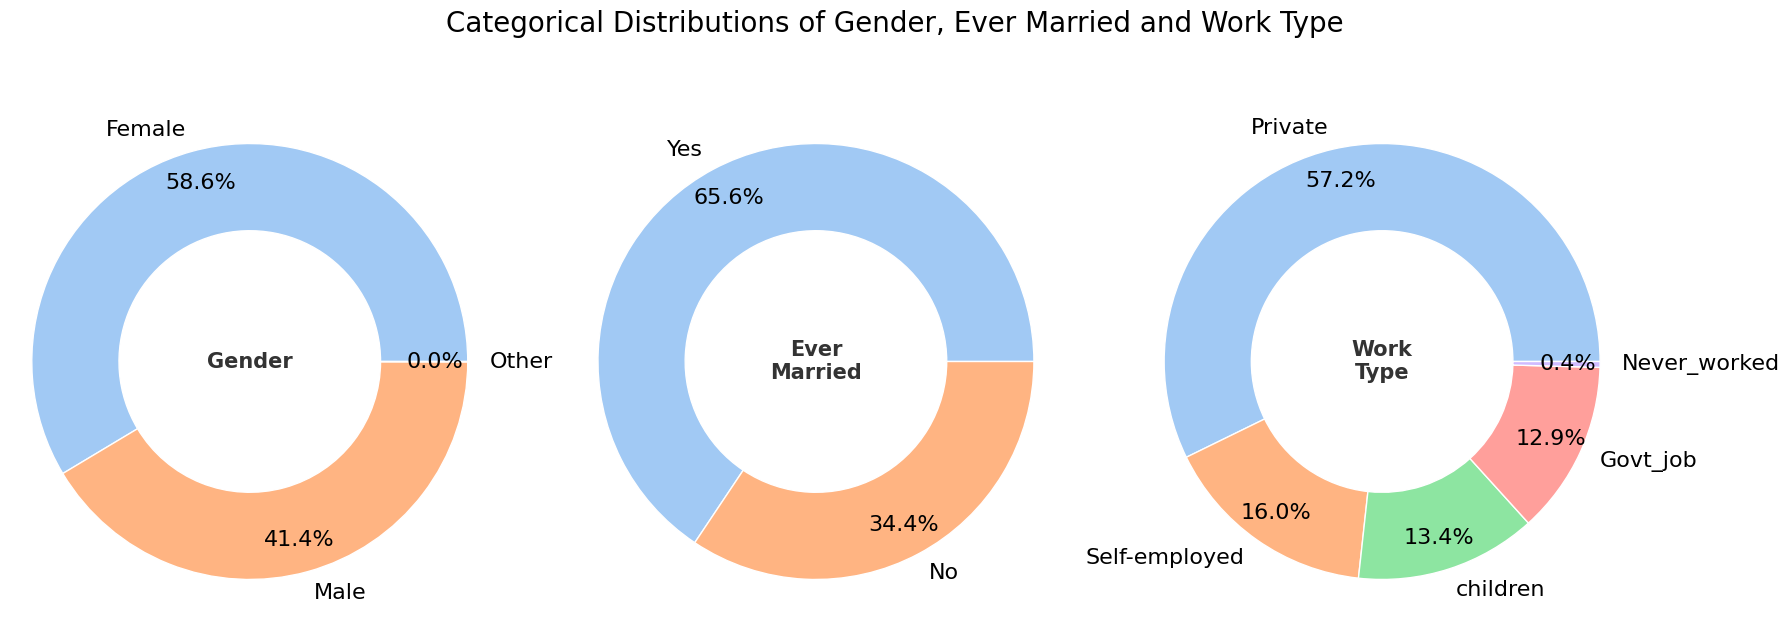

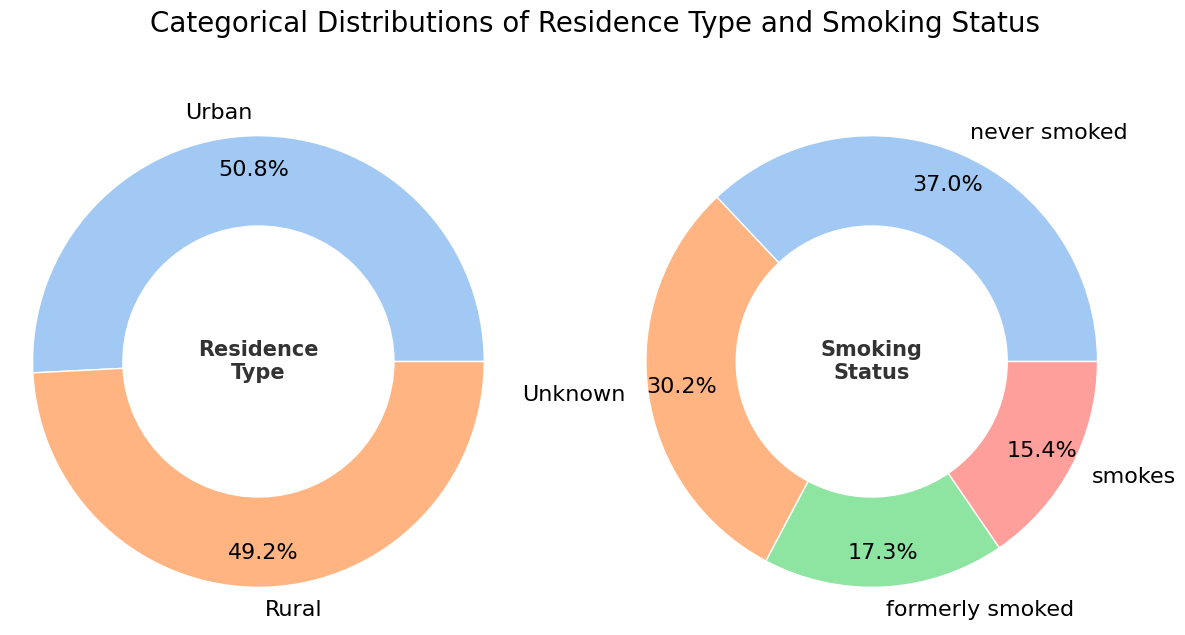

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_donut_on_ax(df, column, ax):
    """
    Plots a donut chart with significantly larger fonts.
    """
    counts = df[column].value_counts()
    labels = counts.index
    sizes = counts.values

    ax.pie(sizes, labels=labels, colors=sns.color_palette('pastel'),
           autopct='%1.1f%%', pctdistance=0.85,
           wedgeprops={'width': 0.4, 'edgecolor': 'white'},
           textprops={'fontsize': 16})

    center_text = column.replace("_", "\n").title()

    ax.text(0, 0, center_text, horizontalalignment='center', verticalalignment='center',
            fontsize=15, fontweight='bold', color='#333333')

    ax.axis('equal')

# Figure 1: First Three Charts
fig1, axes1 = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
cols_fig1 = ['gender', 'ever_married', 'work_type']

for ax, col in zip(axes1.flatten(), cols_fig1):
    plot_donut_on_ax(df, col, ax)

fig1.suptitle("Categorical Distributions of Gender, Ever Married and Work Type", fontsize=20, y=1.05)
plt.tight_layout()
plt.show()

# Figure 2: Next Two Charts
fig2, axes2 = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
cols_fig2 = ['Residence_type', 'smoking_status']

for ax, col in zip(axes2.flatten(), cols_fig2):
    plot_donut_on_ax(df, col, ax)

fig2.suptitle("Categorical Distributions of Residence Type and Smoking Status", fontsize=20, y=1.05)
plt.tight_layout()
plt.show()

In [37]:
!pip install phik

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 14.9 MB/s eta 0:00:00


interval columns not set, guessing: ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']


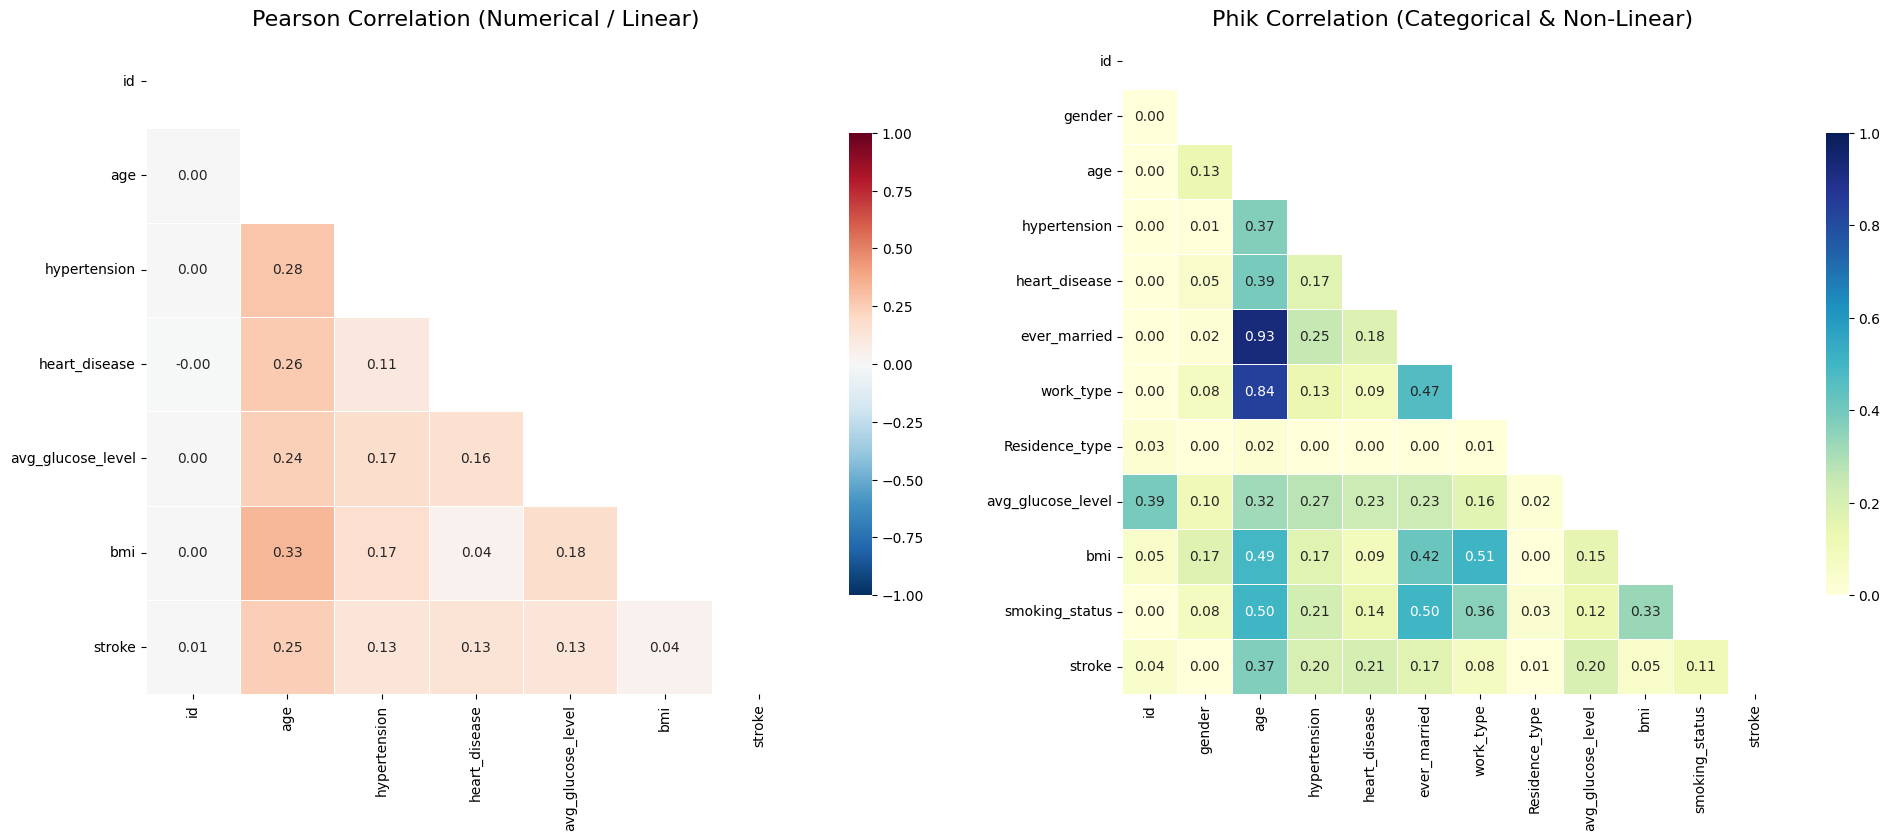

In [38]:
import phik
from phik.report import plot_correlation_matrix

# --- 1. Pearson Correlation (Numerical Only) ---
# We select only numeric columns for Pearson
numeric_df = df.select_dtypes(include=['number'])
pearson_corr = numeric_df.corr(method='pearson')

# --- 2. Phik Correlation (All Variables) ---
# Phik automatically detects types, but we pass the interval columns explicitly
# just to be safe if you have many unique values in a numeric col.
phik_corr = df.phik_matrix()

# --- 3. Plotting ---

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Pearson (Linear)
mask_p = np.triu(np.ones_like(pearson_corr, dtype=bool))

sns.heatmap(pearson_corr, ax=axes[0], annot=True, fmt=".2f", cmap='RdBu_r',
            mask=mask_p, vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .7})
axes[0].set_title('Pearson Correlation (Numerical / Linear)', fontsize=16)


# Plot 2: Phik (Non-Linear & Categorical)
# Mask the upper triangle
mask_k = np.triu(np.ones_like(phik_corr, dtype=bool))

sns.heatmap(phik_corr, ax=axes[1], annot=True, fmt=".2f", cmap='YlGnBu',
            mask=mask_k, vmin=0, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .7})
axes[1].set_title('Phik Correlation (Categorical & Non-Linear)', fontsize=16)

plt.tight_layout()
plt.show()

## Visualisations